# Linear Regression Using Gradient Descent

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Given dataset
X = np.array([50, 60, 70, 80, 90], dtype=float)
y = np.array([150, 180, 210, 240, 270], dtype=float)

print("X:", X)
print("y:", y)
print("X shape:", X.shape)
print("y shape:", y.shape)


X: [50. 60. 70. 80. 90.]
y: [150. 180. 210. 240. 270.]
X shape: (5,)
y shape: (5,)


## 2. Create the `LinearRegressionGD` Class




In [2]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.001, n_iters=100):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0
        self.theta_1 = 0.0
        self.sse_history = []

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self.theta_0 + self.theta_1 * X

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        n = len(X)
        self.theta_0 = 0.0
        self.theta_1 = 0.0
        self.sse_history = []

        for _ in range(self.n_iters):
            predictions = self.predict(X)
            errors = predictions - y

            # Store SSE before the update
            sse = np.sum(errors ** 2)
            self.sse_history.append(sse)

            # Gradients of MSE
            grad_theta_0 = (2 / n) * np.sum(errors)
            grad_theta_1 = (2 / n) * np.sum(errors * X)

            self.theta_0 -= self.learning_rate * grad_theta_0
            self.theta_1 -= self.learning_rate * grad_theta_1

        return self

    def mse(self, X, y):
        predictions = self.predict(X)
        return np.mean((predictions - y) ** 2)

    def plot_training(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

        # SSE over iterations
        axes[0].plot(range(1, len(self.sse_history) + 1), self.sse_history)
        axes[0].set_title("SSE over Iterations")
        axes[0].set_xlabel("Iteration")
        axes[0].set_ylabel("SSE")
        axes[0].grid(True, alpha=0.3)

        # Regression line + data
        x_line = np.linspace(X.min(), X.max(), 100)
        y_line = self.predict(x_line)

        axes[1].scatter(X, y, label="Data points")
        axes[1].plot(x_line, y_line, label="Regression line")
        axes[1].set_title("Regression Line")
        axes[1].set_xlabel("House Size (m²)")
        axes[1].set_ylabel("House Price (thousands)")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


In [3]:
model = LinearRegressionGD(learning_rate=0.001, n_iters=100)
model.fit(X, y)

print("theta_0 =", model.theta_0)
print("theta_1 =", model.theta_1)
print("Final SSE =", model.sse_history[-1])


theta_0 = -1.0055957901462392e+95
theta_1 = -7.326427288635144e+96
Final SSE = 1.6170789775172399e+196


## 4. Prediction



In [4]:
house_size = 70
predicted_price = model.predict(house_size)

print(f"Predicted price for a {house_size} m² house: {predicted_price:.4f} thousand")


Predicted price for a 70 m² house: -512950469783474681601735659150059764001133837647853304062802627266710541831899364891863753559113728.0000 thousand


## 5. Visualization



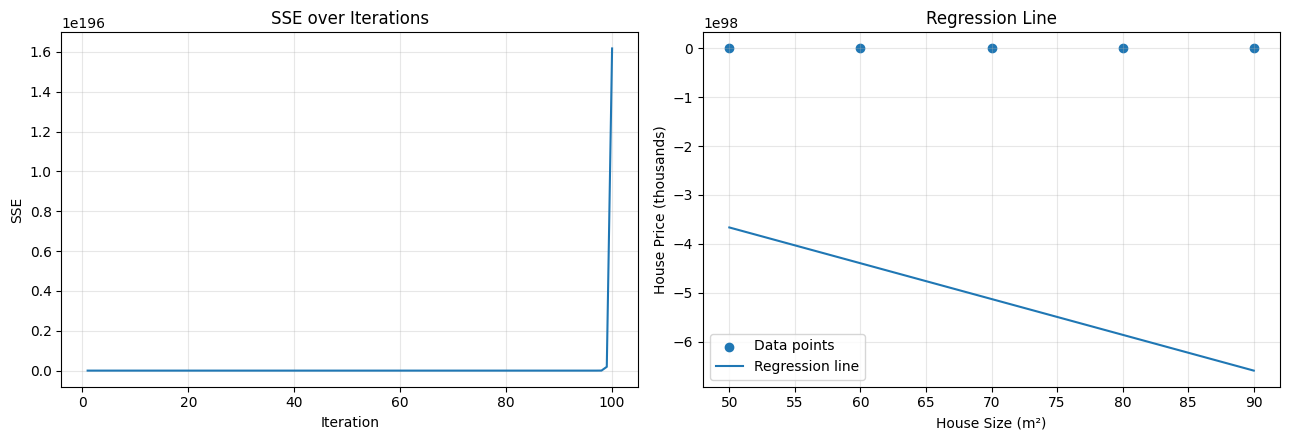

In [5]:
model.plot_training(X, y)


## 6. Experimentation with Learning Rate



In [6]:
learning_rates = {
    "Very Large (0.01)": 0.01,
    "Required (0.001)": 0.001,
    "Stable Reference (0.0001)": 0.0001,
    "Very Small (0.000001)": 0.000001,
}

experiments = {}

for name, lr in learning_rates.items():
    m = LinearRegressionGD(learning_rate=lr, n_iters=100)
    m.fit(X, y)
    experiments[name] = m

    print(f"{name}")
    print(f"  theta_0 = {m.theta_0:.6g}")
    print(f"  theta_1 = {m.theta_1:.6g}")
    print(f"  final SSE = {m.sse_history[-1]:.6g}")
    print(f"  prediction at 70 m² = {m.predict(70):.6g}")
    print()


Very Large (0.01)
  theta_0 = -1.13493e+199
  theta_1 = -8.26873e+200
  final SSE = inf
  prediction at 70 m² = -5.78924e+202

Required (0.001)
  theta_0 = -1.0056e+95
  theta_1 = -7.32643e+96
  final SSE = 1.61708e+196
  prediction at 70 m² = -5.1295e+98

Stable Reference (0.0001)
  theta_0 = 0.0411368
  theta_1 = 2.99944
  final SSE = 0.000331816
  prediction at 70 m² = 210.002

Very Small (0.000001)
  theta_0 = 0.0264038
  theta_1 = 1.92371
  final SSE = 30130.8
  prediction at 70 m² = 134.686



C:\Users\habiba\AppData\Local\Temp\ipykernel_29832\453795969.py:27: RuntimeWarning: overflow encountered in square
  sse = np.sum(errors ** 2)


c:\Users\habiba\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


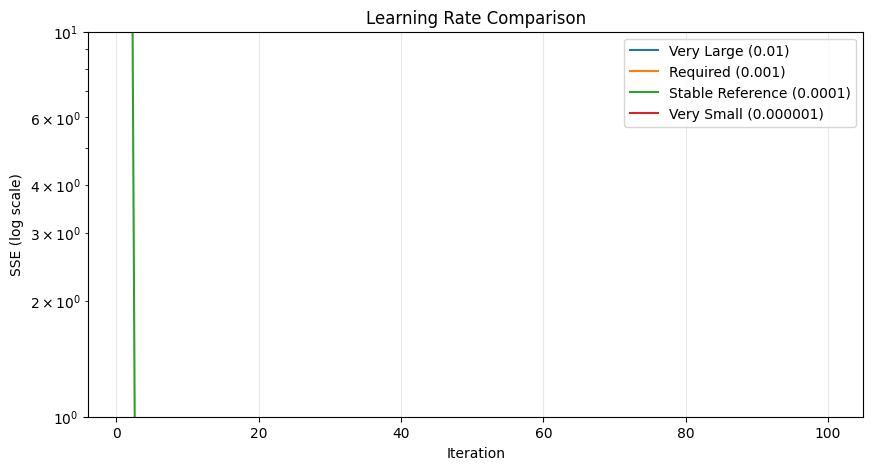

In [7]:
# Plot SSE curves for the learning-rate experiments
plt.figure(figsize=(10, 5))

for name, m in experiments.items():
    # Avoid hiding the useful comparison if a run becomes numerically huge
    history = np.array(m.sse_history)
    safe_history = np.clip(history, 1e-12, 1e300)
    plt.plot(range(1, len(safe_history) + 1), safe_history, label=name)

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("SSE (log scale)")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 7. Bonus: MSE


In [8]:
stable_model = LinearRegressionGD(learning_rate=0.0001, n_iters=1000)
stable_model.fit(X, y)

print("Stable model:")
print("theta_0 =", stable_model.theta_0)
print("theta_1 =", stable_model.theta_1)
print("MSE =", stable_model.mse(X, y))
print("Prediction for 70 m² =", stable_model.predict(70), "thousand")


Stable model:
theta_0 = 0.04084745890968899
theta_1 = 2.9994393442929344
MSE = 6.543195693322487e-05
Prediction for 70 m² = 210.0016015594151 thousand


## 8. Bonus: Normalize X and Compare



In [9]:
# Standardize X
X_mean = X.mean()
X_std = X.std()
X_norm = (X - X_mean) / X_std

normalized_model = LinearRegressionGD(learning_rate=0.001, n_iters=100)
normalized_model.fit(X_norm, y)

# Predict 70 m² after applying the same normalization
x_70_norm = (70 - X_mean) / X_std
pred_70_norm = normalized_model.predict(x_70_norm)

print("Normalized X:", X_norm)
print("theta_0 (normalized model) =", normalized_model.theta_0)
print("theta_1 (normalized model) =", normalized_model.theta_1)
print("Final SSE =", normalized_model.sse_history[-1])
print("Prediction for 70 m² =", pred_70_norm, "thousand")


Normalized X: [-1.41421356 -0.70710678  0.          0.70710678  1.41421356]
theta_0 (normalized model) = 38.100971015430154
theta_1 (normalized model) = 7.697558564229364
Final SSE = 154393.80298957668
Prediction for 70 m² = 38.100971015430154 thousand


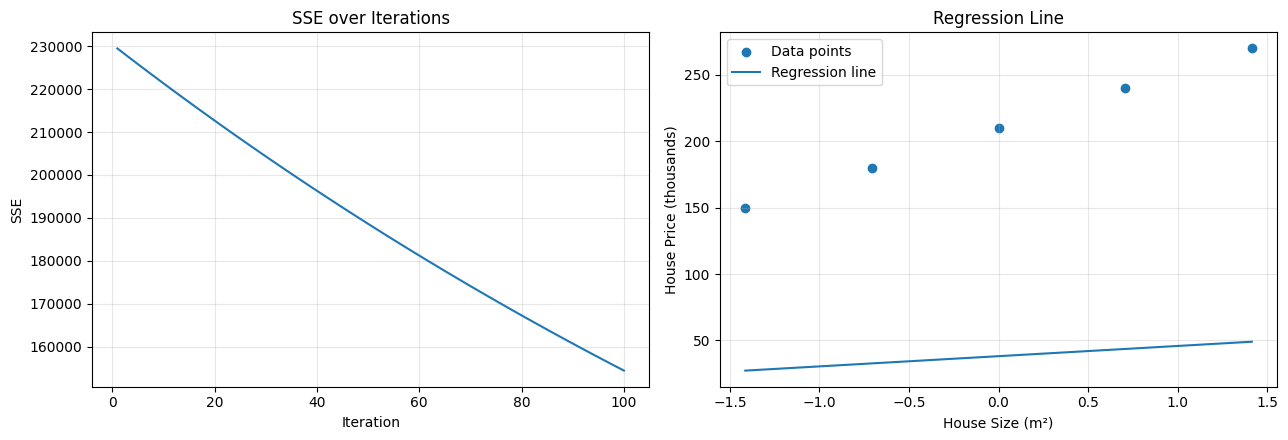

In [10]:
normalized_model.plot_training(X_norm, y)
